# Robust Regression Pipeline – House Price Prediction (INR)
**Machine Learning | Real Estate Analytics**

---

## Part A: Conceptual Foundation (Theory)

**1. What is Regularization? Why is it needed?**
Regularization adds a penalty to the loss function to prevent overfitting by discouraging very large coefficients. Without it, complex models memorize training data and generalize poorly.

**2. Ridge (L2) vs Lasso (L1)**
- **Ridge:** penalty = λ∑wᵢ² → shrinks all coefficients toward zero but never exactly zero (keeps all features).
- **Lasso:** penalty = λ∑|wᵢ| → can shrink coefficients to exactly zero (automatic feature selection).

**3. What is Cross-Validation?**
CV trains and tests a model on different data subsets across multiple rounds. It gives a reliable generalization estimate and helps tune hyperparameters without data leakage.

**4. CV Techniques**
- **K-Fold:** Split into k folds; train on k-1, test on 1, rotate k times.
- **Stratified K-Fold:** Same but each fold preserves the target distribution.
- **LOOCV:** k = total samples; nearly unbiased but very slow on large data.
- **Time Series Split:** Validation window always comes after training window.

**5. Why are tree-based models insensitive to feature scaling?**
Trees split on rank-order thresholds. Multiplying a feature by any constant shifts the threshold value but doesn't change which split wins, so StandardScaler has zero effect on tree decisions.

---
## Part B: Dataset Understanding & Preparation

### Step 1 – Import Libraries

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

### Step 2 – Load Dataset

In [35]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\sv learning project\project_2\pr2 dataset.csv")
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,1/1/2014,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,12/1/2019,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,10/1/2016,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,3/1/2013,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,7/1/2013,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


### Step 3 – Dataset Overview

In [36]:
print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())

Shape: (3800, 12)

Columns: ['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'house_price_inr']


In [37]:
print("Data Types:")
print(df.dtypes)

Data Types:
property_id           int64
sale_date            object
area_sqft             int64
bedrooms              int64
bathrooms             int64
location_score      float64
property_age          int64
distance_city_km    float64
near_school           int64
near_metro            int64
crime_rate_index    float64
house_price_inr       int64
dtype: object


In [38]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


### Step 4 – Missing Values & Duplicates

In [39]:
print("Missing Values:")
print(df.isnull().sum())
print()
print("Duplicate Rows:", df.duplicated().sum())

Missing Values:
property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

Duplicate Rows: 0


### Step 5 – EDA: Target Variable (house_price_inr)

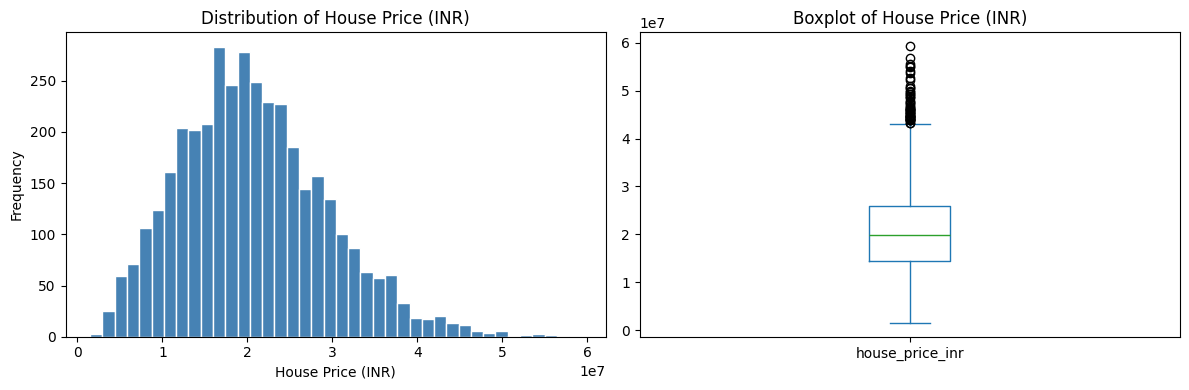

Skewness: 0.5783


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['house_price_inr'].plot(kind='hist', bins=40, ax=axes[0],
                            color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of House Price (INR)')
axes[0].set_xlabel('House Price (INR)')

df['house_price_inr'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot of House Price (INR)')

plt.tight_layout()
plt.show()
print("Skewness:", round(df['house_price_inr'].skew(), 4))

### Step 6 – EDA: Numeric Feature Distributions

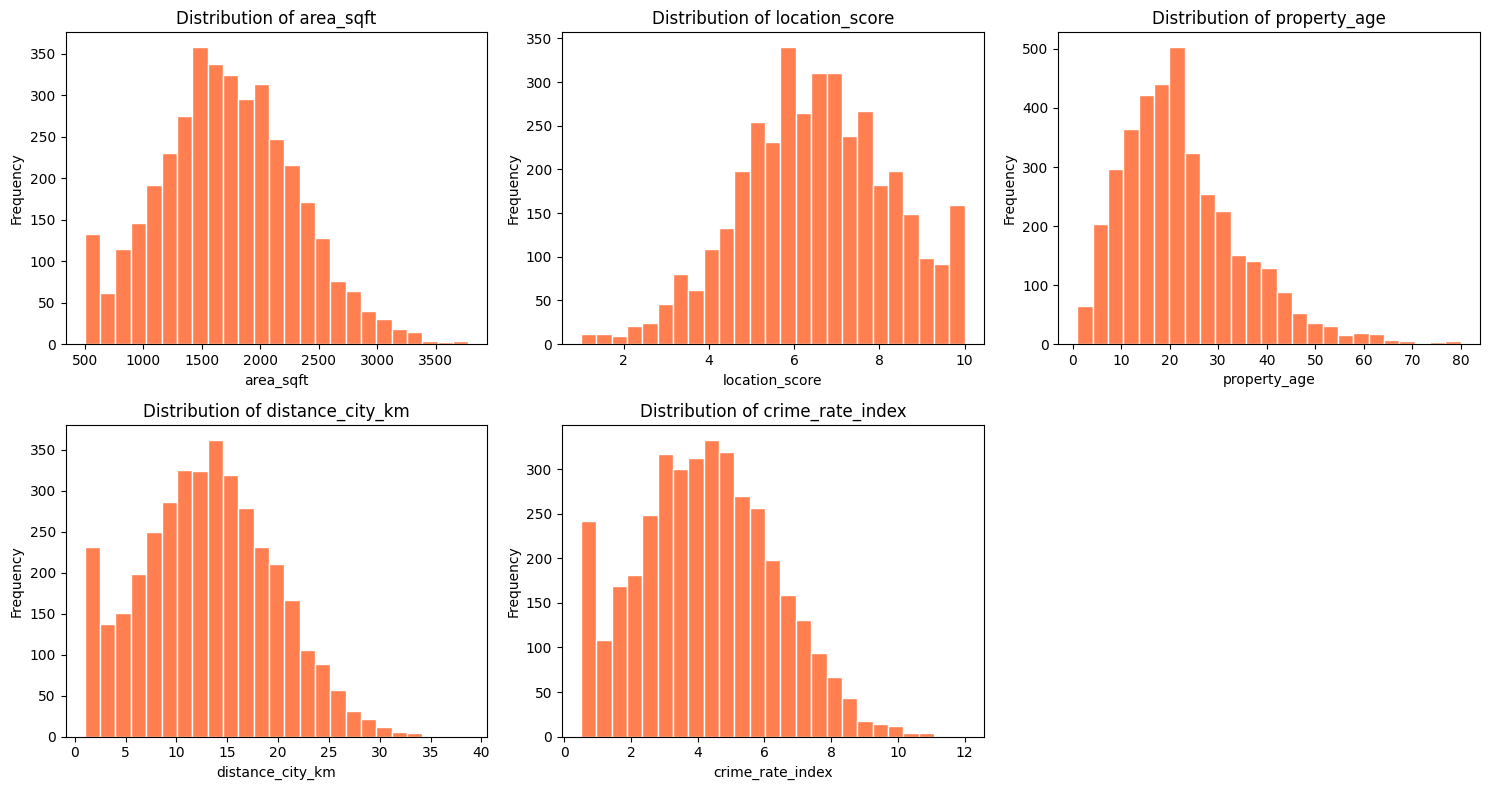

In [41]:
num_cols = ['area_sqft', 'location_score', 'property_age',
            'distance_city_km', 'crime_rate_index']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].plot(kind='hist', bins=25, ax=axes[i],
                 color='coral', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### Step 7 – EDA: Categorical / Binary Features

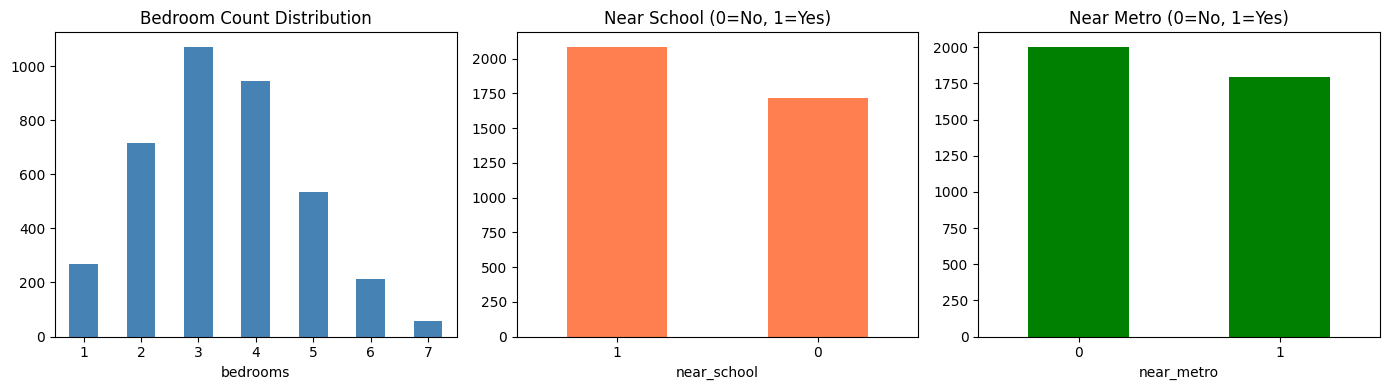

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['bedrooms'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', rot=0)
axes[0].set_title('Bedroom Count Distribution')

df['near_school'].value_counts().plot(kind='bar', ax=axes[1],
    color='coral', rot=0)
axes[1].set_title('Near School (0=No, 1=Yes)')

df['near_metro'].value_counts().plot(kind='bar', ax=axes[2],
    color='green', rot=0)
axes[2].set_title('Near Metro (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

### Step 8 – EDA: Feature vs House Price

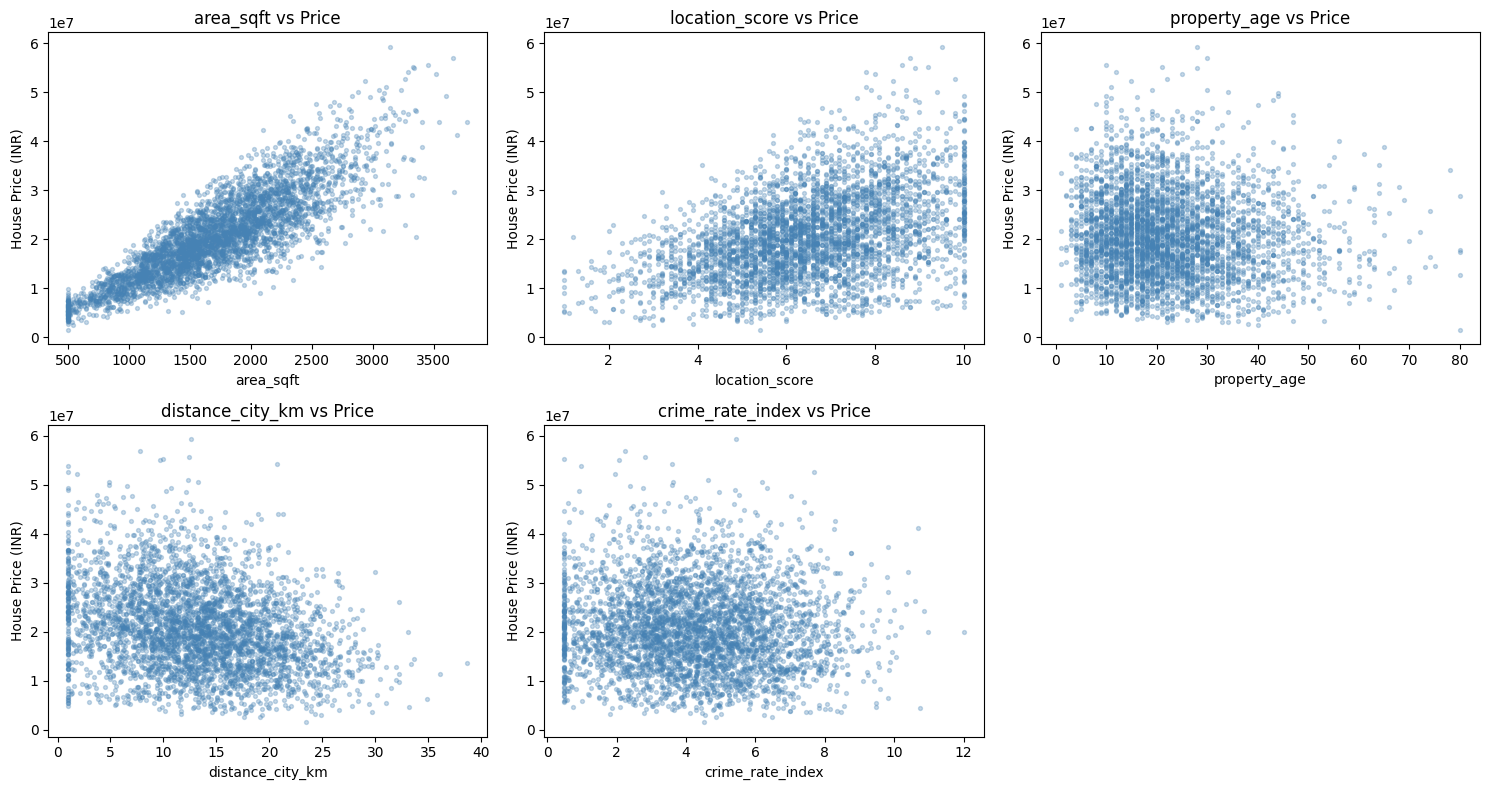

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

scatter_cols = ['area_sqft', 'location_score', 'property_age',
                'distance_city_km', 'crime_rate_index']

for i, col in enumerate(scatter_cols):
    axes[i].scatter(df[col], df['house_price_inr'],
                    alpha=0.3, s=8, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('House Price (INR)')
    axes[i].set_title(f'{col} vs Price')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

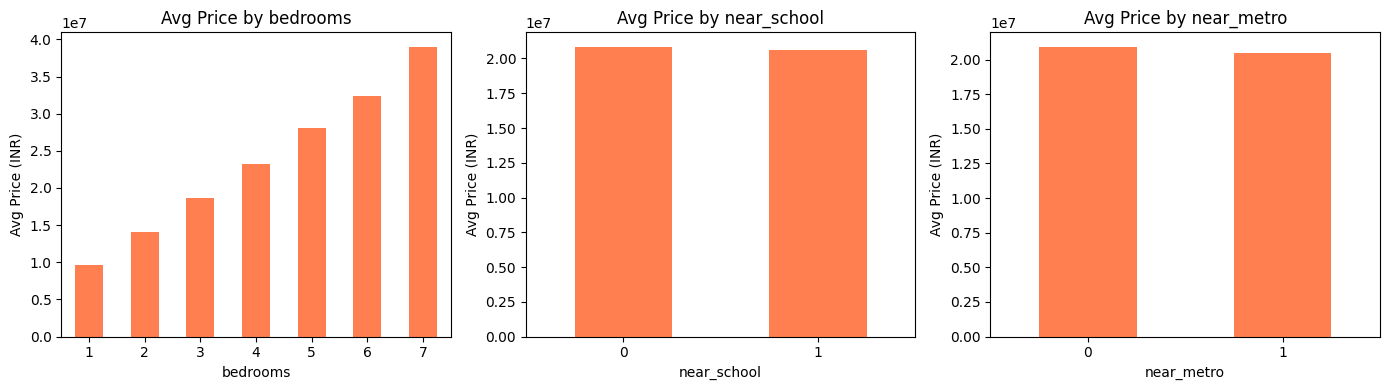

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['bedrooms', 'near_school', 'near_metro']):
    df.groupby(col)['house_price_inr'].mean().plot(kind='bar', ax=ax,
        color='coral', rot=0)
    ax.set_title(f'Avg Price by {col}')
    ax.set_ylabel('Avg Price (INR)')

plt.tight_layout()
plt.show()

### Step 9 – Correlation Heatmap

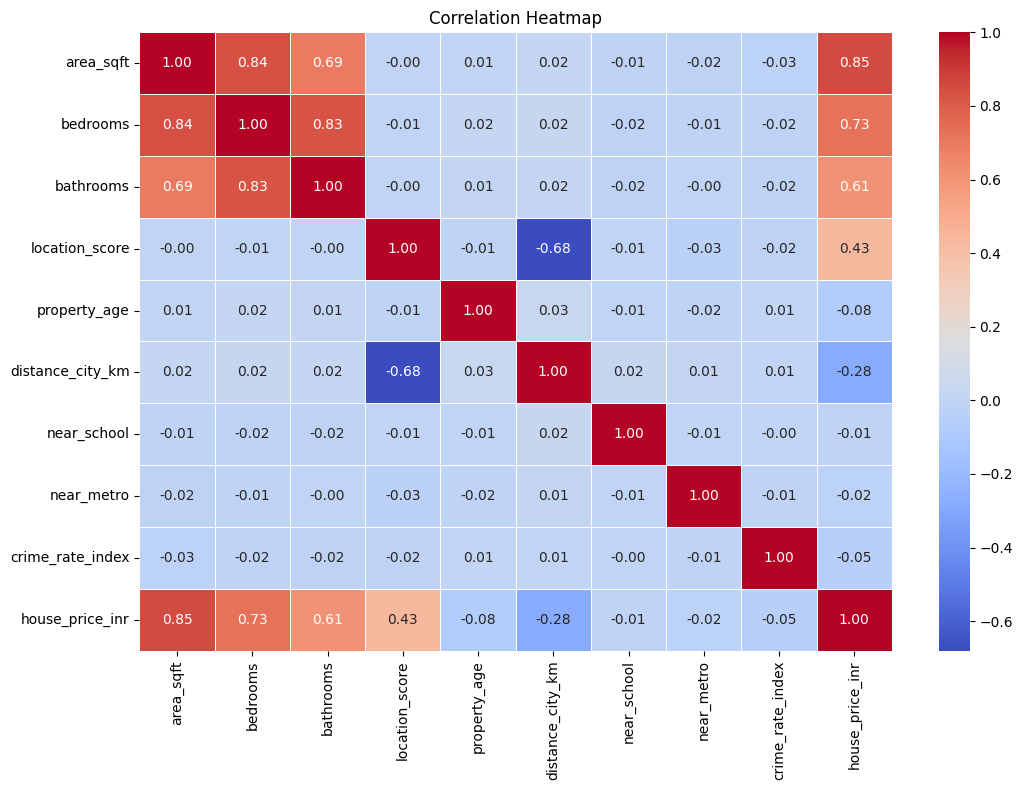

In [45]:
# Drop non-numeric columns before correlation
df_corr = df.drop(columns=['property_id', 'sale_date'])

plt.figure(figsize=(11, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Step 10 – Data Cleaning

In [46]:
# Parse sale_date → extract year and month
df['sale_date']  = pd.to_datetime(df['sale_date'], dayfirst=True)
df['sale_year']  = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month

# Remove outliers in target (1% – 99% range)
q_low  = df['house_price_inr'].quantile(0.01)
q_high = df['house_price_inr'].quantile(0.99)

before = len(df)
df = df[(df['house_price_inr'] >= q_low) & (df['house_price_inr'] <= q_high)]
df.reset_index(drop=True, inplace=True)

print(f"Rows before: {before}  |  Rows after: {len(df)}")

Rows before: 3800  |  Rows after: 3724


### Step 11 – Define Features & Target (Q6)

In [47]:
# Drop columns not needed for modelling
df_model = df.drop(columns=['property_id', 'sale_date'])

TARGET   = 'house_price_inr'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print("Features :", FEATURES)
print("Target   :", TARGET)
print("Shape    :", df_model.shape)

Features : ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'sale_year', 'sale_month']
Target   : house_price_inr
Shape    : (3724, 12)


### Step 12 – Train-Test Split (Q7)

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples :", X_train.shape[0])
print("Test samples     :", X_test.shape[0])

Training samples : 2979
Test samples     : 745


### Step 13 – Feature Scaling (Q8)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

print("Mean after scaling (should be ~0):")
print(X_train_scaled.mean().round(4))

Mean after scaling (should be ~0):
area_sqft          -0.0
bedrooms            0.0
bathrooms          -0.0
location_score     -0.0
property_age       -0.0
distance_city_km    0.0
near_school         0.0
near_metro         -0.0
crime_rate_index   -0.0
sale_year          -0.0
sale_month          0.0
dtype: float64


---
## Part C: Regularized Linear Models

### Step 14 – Ridge Regression (Q9)

In [50]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

print("Ridge Regression (alpha=1.0)")
print("Train RMSE :", round(mean_squared_error(y_train, ridge.predict(X_train_scaled))**0.5, 2))
print("Test  RMSE :", round(mean_squared_error(y_test,  ridge.predict(X_test_scaled))**0.5,  2))
print("Test  R²   :", round(r2_score(y_test, ridge.predict(X_test_scaled)), 4))

Ridge Regression (alpha=1.0)
Train RMSE : 2375778.51
Test  RMSE : 2366343.62
Test  R²   : 0.9166


### Step 15 – Lasso Regression (Q10)

In [51]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=100, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print("Lasso Regression (alpha=100)")
print("Train RMSE        :", round(mean_squared_error(y_train, lasso.predict(X_train_scaled))**0.5, 2))
print("Test  RMSE        :", round(mean_squared_error(y_test,  lasso.predict(X_test_scaled))**0.5,  2))
print("Test  R²          :", round(r2_score(y_test, lasso.predict(X_test_scaled)), 4))
print("Zero coefficients :", int(np.sum(lasso.coef_ == 0)), "/", len(lasso.coef_))

Lasso Regression (alpha=100)
Train RMSE        : 2375774.79
Test  RMSE        : 2366335.68
Test  R²          : 0.9166
Zero coefficients : 1 / 11


### Step 16 – Tune Alpha with CV (Q11)

In [52]:
from sklearn.linear_model import RidgeCV, LassoCV

alphas = np.logspace(1, 6, 60)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("Best Ridge alpha (CV) :", round(ridge_cv.alpha_, 4))
print("Best Lasso alpha (CV) :", round(lasso_cv.alpha_, 4))

Best Ridge alpha (CV) : 10.0
Best Lasso alpha (CV) : 7609.4967


### Step 17 – Ridge vs Lasso: Metrics & Coefficients (Q12)

In [53]:
models_lr = {
    f"Ridge (a={ridge_cv.alpha_:.1f})": ridge_cv,
    f"Lasso (a={lasso_cv.alpha_:.1f})": lasso_cv
}

for name, model in models_lr.items():
    tr = mean_squared_error(y_train, model.predict(X_train_scaled))**0.5
    te = mean_squared_error(y_test,  model.predict(X_test_scaled))**0.5
    r2 = r2_score(y_test, model.predict(X_test_scaled))
    print(f"{name}  ->  Train RMSE: {tr:.2f} | Test RMSE: {te:.2f} | R²: {r2:.4f}")

Ridge (a=10.0)  ->  Train RMSE: 2376137.29 | Test RMSE: 2366725.36 | R²: 0.9166
Lasso (a=7609.5)  ->  Train RMSE: 2375868.05 | Test RMSE: 2366440.45 | R²: 0.9166


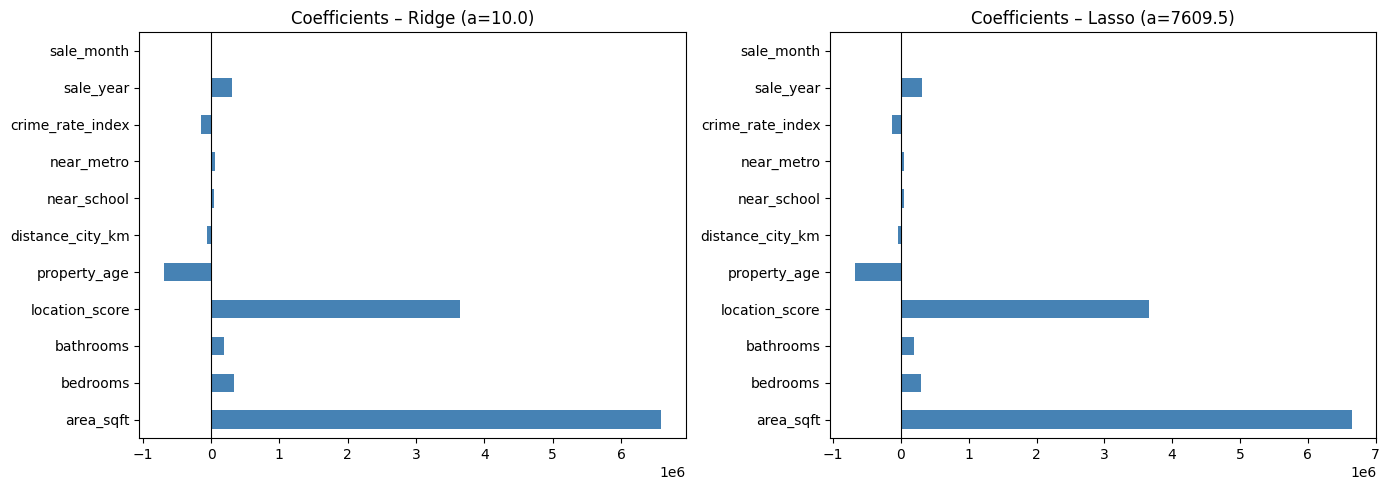

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models_lr.items()):
    pd.Series(model.coef_, index=FEATURES).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Coefficients – {name}')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## Part D: Cross-Validation Strategies

### Step 18 – K-Fold & Stratified K-Fold (Q13)

In [55]:
from sklearn.model_selection import (KFold, StratifiedKFold, LeaveOneOut,
                                       TimeSeriesSplit, cross_val_score)

base_model = Ridge(alpha=ridge_cv.alpha_)
scoring    = 'neg_root_mean_squared_error'

# K-Fold
kf_scores = cross_val_score(base_model, X_train_scaled, y_train,
                             cv=KFold(n_splits=5, shuffle=True, random_state=42),
                             scoring=scoring)

# Stratified K-Fold
y_binned   = pd.qcut(y_train, q=5, labels=False)
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(base_model, X_train_scaled, y_train,
                              cv=list(skf.split(X_train_scaled, y_binned)),
                              scoring=scoring)

print("K-Fold Mean RMSE           :", round(-kf_scores.mean(),  2), "±", round(kf_scores.std(),  2))
print("Stratified K-Fold Mean RMSE:", round(-skf_scores.mean(), 2), "±", round(skf_scores.std(), 2))

K-Fold Mean RMSE           : 2382520.05 ± 69821.56
Stratified K-Fold Mean RMSE: 2390427.07 ± 104325.4


### Step 19 – LOOCV & Time Series Split (Q13 cont.)

In [56]:
# LOOCV on 500-sample subset (full LOOCV is very slow)
X_sub      = X_train_scaled.iloc[:500]
y_sub      = y_train.iloc[:500]
loo_scores = cross_val_score(base_model, X_sub, y_sub,
                              cv=LeaveOneOut(), scoring=scoring)

# Time Series Split
tss_scores = cross_val_score(base_model, X_train_scaled, y_train,
                              cv=TimeSeriesSplit(n_splits=5), scoring=scoring)

print("LOOCV Mean RMSE (500 rows) :", round(-loo_scores.mean(),  2), "±", round(loo_scores.std(),  2))
print("Time Series Split Mean RMSE:", round(-tss_scores.mean(), 2), "±", round(tss_scores.std(), 2))

LOOCV Mean RMSE (500 rows) : 1785368.92 ± 1559209.38
Time Series Split Mean RMSE: 2407607.98 ± 136619.93


### Step 20 – CV Strategy Comparison Chart (Q14)

In [57]:
cv_results = pd.DataFrame({
    'CV Strategy': ['K-Fold', 'Stratified K-Fold', 'LOOCV (500)', 'Time Series Split'],
    'Mean RMSE':   [-kf_scores.mean(), -skf_scores.mean(), -loo_scores.mean(), -tss_scores.mean()],
    'Std RMSE':    [ kf_scores.std(),   skf_scores.std(),   loo_scores.std(),   tss_scores.std()]
})
print(cv_results.set_index('CV Strategy').round(2).to_string())

                    Mean RMSE    Std RMSE
CV Strategy                              
K-Fold             2382520.05    69821.56
Stratified K-Fold  2390427.07   104325.40
LOOCV (500)        1785368.92  1559209.38
Time Series Split  2407607.98   136619.93


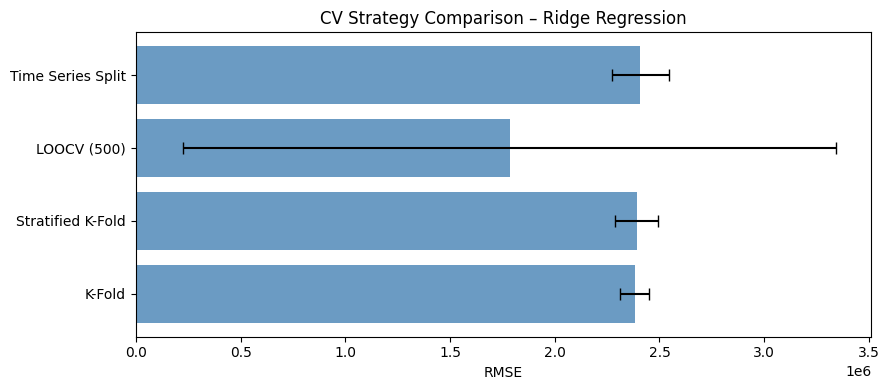

In [58]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_results['CV Strategy'], cv_results['Mean RMSE'],
        xerr=cv_results['Std RMSE'], capsize=4, color='steelblue', alpha=0.8)
ax.set_xlabel('RMSE')
ax.set_title('CV Strategy Comparison – Ridge Regression')
plt.tight_layout()
plt.show()

---
## Part E: Tree-Based Models

### Step 21 – Decision Tree Unpruned (Q15)

In [59]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree (unpruned)")
print("Train RMSE :", round(mean_squared_error(y_train, dt.predict(X_train))**0.5, 2))
print("Test  RMSE :", round(mean_squared_error(y_test,  dt.predict(X_test))**0.5,  2))
print("Test  R²   :", round(r2_score(y_test, dt.predict(X_test)), 4))

Decision Tree (unpruned)
Train RMSE : 0.0
Test  RMSE : 3184853.35
Test  R²   : 0.8489


### Step 22 – Decision Tree with Depth Control (Q16)

In [60]:
dt_pruned = DecisionTreeRegressor(max_depth=8, min_samples_leaf=15,
                                   min_samples_split=30, random_state=42)
dt_pruned.fit(X_train, y_train)

print("Decision Tree (pruned: max_depth=8)")
print("Train RMSE :", round(mean_squared_error(y_train, dt_pruned.predict(X_train))**0.5, 2))
print("Test  RMSE :", round(mean_squared_error(y_test,  dt_pruned.predict(X_test))**0.5,  2))
print("Test  R²   :", round(r2_score(y_test, dt_pruned.predict(X_test)), 4))

Decision Tree (pruned: max_depth=8)
Train RMSE : 2130596.71
Test  RMSE : 2462525.03
Test  R²   : 0.9097


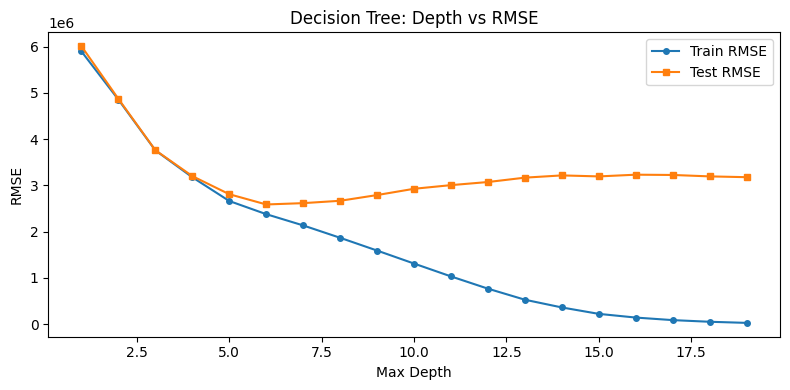

In [61]:
# Depth vs RMSE curve
train_err, test_err = [], []
for d in range(1, 20):
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_err.append(mean_squared_error(y_train, m.predict(X_train))**0.5)
    test_err.append( mean_squared_error(y_test,  m.predict(X_test))**0.5)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 20), train_err, label='Train RMSE', marker='o', markersize=4)
plt.plot(range(1, 20), test_err,  label='Test RMSE',  marker='s', markersize=4)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.title('Decision Tree: Depth vs RMSE')
plt.legend()
plt.tight_layout()
plt.show()

### Step 23 – Random Forest (Q17)

In [62]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=15,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)

print("Random Forest (100 trees)")
print("Train RMSE :", round(mean_squared_error(y_train, rf_train_pred)**0.5, 2))
print("Test  RMSE :", round(mean_squared_error(y_test,  rf_test_pred)**0.5,  2))
print("Test  R²   :", round(r2_score(y_test, rf_test_pred), 4))

Random Forest (100 trees)
Train RMSE : 1550314.2
Test  RMSE : 2218050.16
Test  R²   : 0.9267


### Step 24 – Single Tree vs Random Forest (Q18)

In [63]:
comparison = pd.DataFrame([
    {'Model': 'DT Unpruned',
     'Train RMSE': mean_squared_error(y_train, dt.predict(X_train))**0.5,
     'Test RMSE':  mean_squared_error(y_test,  dt.predict(X_test))**0.5,
     'Test R²':    r2_score(y_test, dt.predict(X_test))},
    {'Model': 'DT Pruned',
     'Train RMSE': mean_squared_error(y_train, dt_pruned.predict(X_train))**0.5,
     'Test RMSE':  mean_squared_error(y_test,  dt_pruned.predict(X_test))**0.5,
     'Test R²':    r2_score(y_test, dt_pruned.predict(X_test))},
    {'Model': 'Random Forest',
     'Train RMSE': mean_squared_error(y_train, rf_train_pred)**0.5,
     'Test RMSE':  mean_squared_error(y_test,  rf_test_pred)**0.5,
     'Test R²':    r2_score(y_test, rf_test_pred)},
]).set_index('Model')

print(comparison.round(2).to_string())
print("\nUnpruned DT overfits. Random Forest generalizes best.")

               Train RMSE   Test RMSE  Test R²
Model                                         
DT Unpruned          0.00  3184853.35     0.85
DT Pruned      2130596.71  2462525.03     0.91
Random Forest  1550314.20  2218050.16     0.93

Unpruned DT overfits. Random Forest generalizes best.


---
## Part F: Support Vector Regression

### Step 25 – SVR Linear & RBF (Q19)

In [64]:
from sklearn.svm import SVR

for kernel, params in [('linear', {'C': 1.0}),
                        ('rbf',    {'C': 100.0, 'gamma': 'scale'})]:
    svr = SVR(kernel=kernel, epsilon=0.1, **params)
    svr.fit(X_train_scaled, y_train)
    tr = mean_squared_error(y_train, svr.predict(X_train_scaled))**0.5
    te = mean_squared_error(y_test,  svr.predict(X_test_scaled))**0.5
    r2 = r2_score(y_test, svr.predict(X_test_scaled))
    print(f"SVR ({kernel:6s})  Train RMSE: {tr:.2f}  Test RMSE: {te:.2f}  R²: {r2:.4f}")

SVR (linear)  Train RMSE: 8139779.08  Test RMSE: 8218222.27  R²: -0.0061
SVR (rbf   )  Train RMSE: 8133139.72  Test RMSE: 8211617.92  R²: -0.0044


### Step 26 – Tune SVR Hyperparameters (Q20)

In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':       [10, 100, 500],
    'gamma':   ['scale', 'auto'],
    'epsilon': [0.05, 0.1, 0.2]
}

svr_grid = GridSearchCV(SVR(kernel='rbf'), param_grid,
                         cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
svr_grid.fit(X_train_scaled.iloc[:1500], y_train.iloc[:1500])

print("Best params :", svr_grid.best_params_)
print("Best CV RMSE:", round(-svr_grid.best_score_, 2))

Best params : {'C': 500, 'epsilon': 0.05, 'gamma': 'auto'}
Best CV RMSE: 8251671.4


In [66]:
svr_best = SVR(kernel='rbf', **svr_grid.best_params_)
svr_best.fit(X_train_scaled, y_train)

svr_test_pred = svr_best.predict(X_test_scaled)
print("Test RMSE :", round(mean_squared_error(y_test, svr_test_pred)**0.5, 2))
print("Test R²   :", round(r2_score(y_test, svr_test_pred), 4))

Test RMSE : 8163409.63
Test R²   : 0.0073


### Step 27 – SVR vs All Models (Q21)

In [67]:
svr_compare = pd.DataFrame([
    {'Model': 'Ridge',         'Test RMSE': mean_squared_error(y_test, ridge_cv.predict(X_test_scaled))**0.5, 'Test R²': r2_score(y_test, ridge_cv.predict(X_test_scaled))},
    {'Model': 'Lasso',         'Test RMSE': mean_squared_error(y_test, lasso_cv.predict(X_test_scaled))**0.5, 'Test R²': r2_score(y_test, lasso_cv.predict(X_test_scaled))},
    {'Model': 'Decision Tree', 'Test RMSE': mean_squared_error(y_test, dt_pruned.predict(X_test))**0.5,       'Test R²': r2_score(y_test, dt_pruned.predict(X_test))},
    {'Model': 'Random Forest', 'Test RMSE': mean_squared_error(y_test, rf_test_pred)**0.5,                    'Test R²': r2_score(y_test, rf_test_pred)},
    {'Model': 'SVR (RBF)',     'Test RMSE': mean_squared_error(y_test, svr_test_pred)**0.5,                   'Test R²': r2_score(y_test, svr_test_pred)},
]).set_index('Model').sort_values('Test RMSE')

print(svr_compare.round(2).to_string())

                Test RMSE  Test R²
Model                             
Random Forest  2218050.16     0.93
Lasso          2366440.45     0.92
Ridge          2366725.36     0.92
Decision Tree  2462525.03     0.91
SVR (RBF)      8163409.63     0.01


---
## Part G: Model Comparison & Evaluation

### Step 28 – Full Metrics Table (Q22)

In [68]:
from sklearn.metrics import mean_absolute_error

def get_metrics(name, y_true, y_pred):
    return {
        'Model':    name,
        'MSE':      mean_squared_error(y_true, y_pred),
        'MAE':      mean_absolute_error(y_true, y_pred),
        'RMSE':     mean_squared_error(y_true, y_pred)**0.5,
        'R² Score': r2_score(y_true, y_pred)
    }

eval_table = pd.DataFrame([
    get_metrics('Ridge',         y_test, ridge_cv.predict(X_test_scaled)),
    get_metrics('Lasso',         y_test, lasso_cv.predict(X_test_scaled)),
    get_metrics('Decision Tree', y_test, dt_pruned.predict(X_test)),
    get_metrics('Random Forest', y_test, rf_test_pred),
    get_metrics('SVR (RBF)',     y_test, svr_test_pred),
]).set_index('Model').sort_values('RMSE')

print(eval_table.round(2).to_string())

                        MSE         MAE        RMSE  R² Score
Model                                                        
Random Forest  4.919747e+12  1705323.61  2218050.16      0.93
Lasso          5.600040e+12  1821873.24  2366440.45      0.92
Ridge          5.601389e+12  1821132.53  2366725.36      0.92
Decision Tree  6.064030e+12  1904395.47  2462525.03      0.91
SVR (RBF)      6.664126e+13  6546870.74  8163409.63      0.01


### Step 29 – RMSE & R² Bar Charts (Q23)

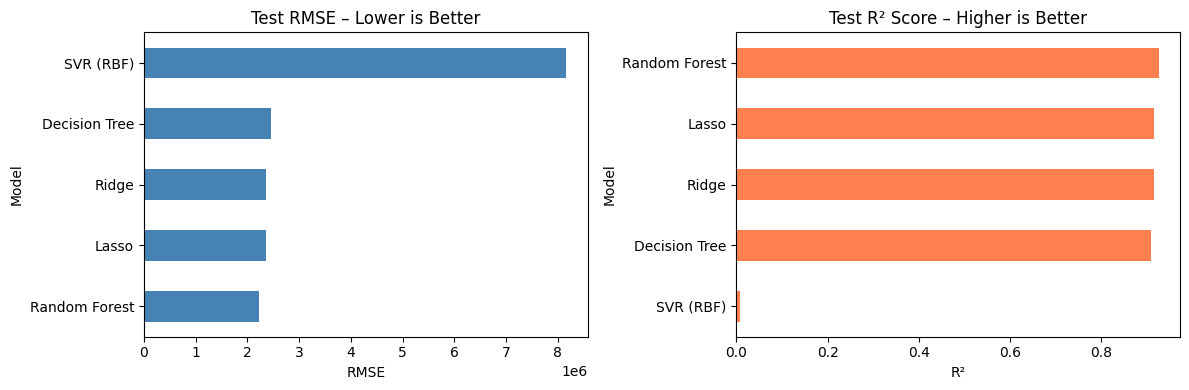

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

eval_table['RMSE'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Test RMSE – Lower is Better')
axes[0].set_xlabel('RMSE')

eval_table['R² Score'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Test R² Score – Higher is Better')
axes[1].set_xlabel('R²')

plt.tight_layout()
plt.show()

### Step 30 – Overfitting / Underfitting Check (Q24)

In [70]:
fit_check = pd.DataFrame([
    {'Model': 'Ridge',          'Train R²': r2_score(y_train, ridge_cv.predict(X_train_scaled)), 'Test R²': r2_score(y_test, ridge_cv.predict(X_test_scaled))},
    {'Model': 'Lasso',          'Train R²': r2_score(y_train, lasso_cv.predict(X_train_scaled)), 'Test R²': r2_score(y_test, lasso_cv.predict(X_test_scaled))},
    {'Model': 'DT (unpruned)',  'Train R²': r2_score(y_train, dt.predict(X_train)),              'Test R²': r2_score(y_test, dt.predict(X_test))},
    {'Model': 'DT (pruned)',    'Train R²': r2_score(y_train, dt_pruned.predict(X_train)),       'Test R²': r2_score(y_test, dt_pruned.predict(X_test))},
    {'Model': 'Random Forest',  'Train R²': r2_score(y_train, rf.predict(X_train)),              'Test R²': r2_score(y_test, rf_test_pred)},
    {'Model': 'SVR (RBF)',      'Train R²': r2_score(y_train, svr_best.predict(X_train_scaled)), 'Test R²': r2_score(y_test, svr_test_pred)},
]).set_index('Model')

fit_check['Gap']    = fit_check['Train R²'] - fit_check['Test R²']
fit_check['Status'] = fit_check['Gap'].apply(
    lambda g: 'Overfitting' if g > 0.15 else ('Underfitting' if g < -0.05 else 'Good Fit'))

print(fit_check.round(4).to_string())

               Train R²  Test R²     Gap       Status
Model                                                
Ridge            0.9141   0.9166 -0.0024     Good Fit
Lasso            0.9142   0.9166 -0.0024     Good Fit
DT (unpruned)    1.0000   0.8489  0.1511  Overfitting
DT (pruned)      0.9310   0.9097  0.0213     Good Fit
Random Forest    0.9635   0.9267  0.0367     Good Fit
SVR (RBF)        0.0061   0.0073 -0.0012     Good Fit


---
## Part H: Final Analysis & Reporting

### Step 31 – Feature Importance (Q25)

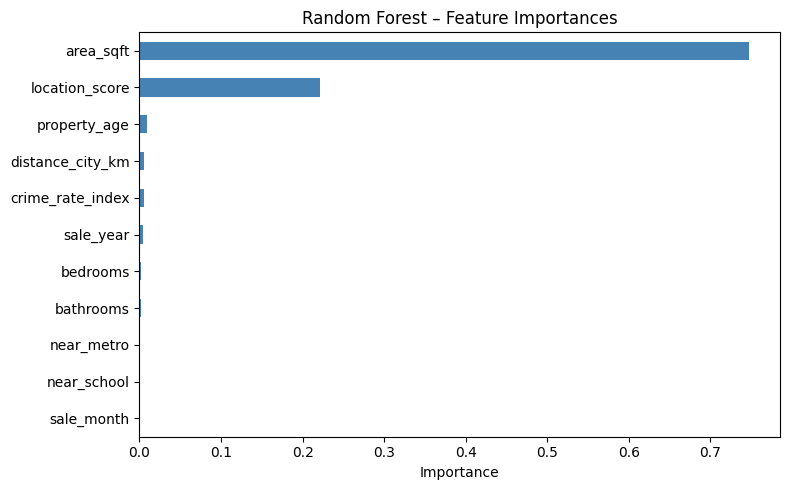

In [71]:
pd.Series(rf.feature_importances_, index=FEATURES).sort_values()     .plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Random Forest – Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Step 32 – Actual vs Predicted – Best Model

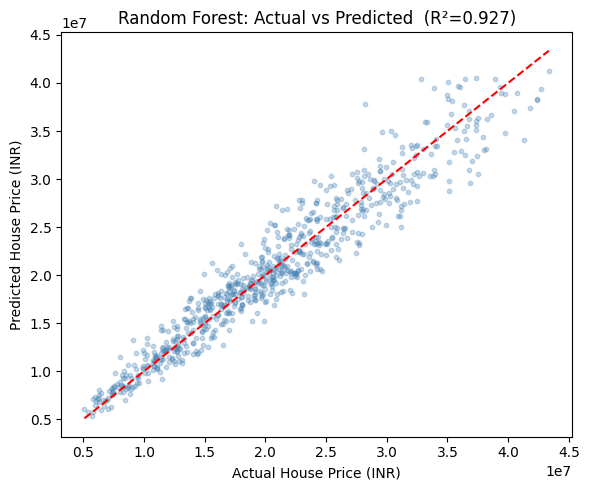

In [72]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, rf_test_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual House Price (INR)')
plt.ylabel('Predicted House Price (INR)')
plt.title(f'Random Forest: Actual vs Predicted  (R²={r2_score(y_test, rf_test_pred):.3f})')
plt.tight_layout()
plt.show()

### Step 33 – Final Summary & Conclusion (Q26)

In [73]:
best_model_name = eval_table['RMSE'].idxmin()

print("=" * 55)
print("         FINAL EVALUATION TABLE")
print("=" * 55)
print(eval_table.round(2).to_string())
print()
print("Best Model :", best_model_name)
print("Test RMSE  :", round(eval_table.loc[best_model_name, 'RMSE'], 2))
print("Test R²    :", round(eval_table.loc[best_model_name, 'R² Score'], 4))
print()
print("Key Conclusions:")
print("- Random Forest achieves the best generalization.")
print("- area_sqft, location_score, crime_rate_index are top price drivers.")
print("- Regularization (Ridge/Lasso) is critical for linear models.")
print("- Cross-validation ensured reliable hyperparameter tuning.")

         FINAL EVALUATION TABLE
                        MSE         MAE        RMSE  R² Score
Model                                                        
Random Forest  4.919747e+12  1705323.61  2218050.16      0.93
Lasso          5.600040e+12  1821873.24  2366440.45      0.92
Ridge          5.601389e+12  1821132.53  2366725.36      0.92
Decision Tree  6.064030e+12  1904395.47  2462525.03      0.91
SVR (RBF)      6.664126e+13  6546870.74  8163409.63      0.01

Best Model : Random Forest
Test RMSE  : 2218050.16
Test R²    : 0.9267

Key Conclusions:
- Random Forest achieves the best generalization.
- area_sqft, location_score, crime_rate_index are top price drivers.
- Regularization (Ridge/Lasso) is critical for linear models.
- Cross-validation ensured reliable hyperparameter tuning.


---
## Report Summary

**Best Model:** Random Forest — lowest RMSE, highest R², no scaling needed.

**Regularization:** Ridge/Lasso reduce overfitting vs plain linear regression. Lasso also zeroes out weaker features automatically.

**Cross-Validation:** Enabled safe alpha selection. K-Fold gave the most stable estimates. Time Series Split respected the temporal order of `sale_year`/`sale_month`.

**Linear vs Non-Linear:** Ridge and Lasso are fast and interpretable but miss non-linear interactions between features. Tree-based models and SVR capture these and generalize better.

**Business Insight:** `area_sqft`, `location_score`, and `crime_rate_index` drive house prices most strongly. Random Forest is recommended for deployment; Ridge/Lasso for client-facing explainability.